# PLANT LEAF DISEASE DETECTION

# 1. Business Understanding

## 1.1 Project Overview

Agriculture is a key pillar of food security and economic growth globally and particularly in developing countries where a large percentage of the population depends on farming for their livelihood. However, crop diseases remain one of the major threats to agricultural productivity, leading to reduced yields, financial losses, and food insecurity.

In this project, we focus on the detection of plant leaf diseases in corn, tomato and potato crops using image classification techniques. The goal is to build a machine learning model capable of identifying whether a plant leaf is healthy or diseased based on visual symptoms. By automating disease detection, farmers can take timely action to prevent disease spread, improve crop health, and reduce reliance on manual inspection, which is often slow, inaccurate, and requires expert knowledge.

## 1.2 Problem Statement

Crop diseases such as blight, leaf spots and rust significantly affect the productivity of corn, tomato and potato plants. Traditional disease detection relies heavily on manual observation by farmers or agricultural experts, which is both time-consuming and prone to human error.

There is therefore a need for a technological solution that can accurately and efficiently detect and classify plant leaf diseases at an early stage. This will help farmers make informed decisions on disease management, reduce crop losses, and improve overall agricultural productivity.

## 1.3 Business Objectives

### 1.3.1 Main Objective

To develop an image classification model that can automatically detect and classify leaf diseases in corn, tomato, and potato plants.

### 1.3.2 Specific Objectives

- To collect and preprocess images of corn, tomato, and potato leaves (both healthy and diseased).

- To train and evaluate a machine learning model capable of identifying disease types based on leaf images.

- To compare model performance using different classification algorithms.

- To provide a simple, user-friendly interface that can assist farmers in identifying crop diseases through image uploads.

### 1.3.3 Research Questions

- What types of diseases affect corn, tomato, and potato leaves?

- Can image classification accurately identify diseased leaves?

- Which model gives the best results in detecting plant leaf diseases?

- How can the model’s results be presented in a way that is easy for farmers to understand?

## 1.4 Success Criteria

- The model achieves an accuracy of 90% or higher on test images.

- It correctly identifies and classifies diseases in all three crops.

- It has a low number of false results (wrong predictions).

- A simple system or interface is developed for easy use by farmers.

# 2. Data Understanding

The dataset used in this project comes from [Mendeley Data — “PlantVillage Dataset: Potato Leaf Disease”](https://data.mendeley.com/datasets/tywbtsjrjv/1)

It contains labeled images of potato leaves under 10 categories


Data Summary:
- Total images: 15848 original images.
- Classes: 10
- Format: JPEG
- Resolution: Variable, to be resized to 224×224 for model training
- Image collection: Captured under field and controlled lighting conditions

## Loading Our Dataset

In [1]:
import tensorflow as tf
import os
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight



# Path to your dataset folder
dataset_path = "Plant disease dataset"

# Load dataset 
data = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(224, 224),   
    batch_size=32,
    shuffle=True
)

# Show all class names
print("Classes found:")
print(data.class_names)

Found 15848 files belonging to 10 classes.
Classes found:
['Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy_aug', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


## Counting all Images in each class

In [2]:
# count of images from all our classes

dataset_path = "Plant disease dataset"

# Get class names 
classes = sorted(os.listdir(dataset_path))

# Count images in each class
print("Class Counts:\n")
for class_name in classes:
    class_dir = os.path.join(dataset_path, class_name)
    count = len(os.listdir(class_dir))
    print(f"{class_name}: {count} images")

Class Counts:

Corn___Cercospora_leaf_spot Gray_leaf_spot: 513 images
Corn___Common_rust: 1192 images
Corn___Northern_Leaf_Blight: 985 images
Corn___healthy: 1162 images
Potato___Early_blight: 2496 images
Potato___Late_blight: 2500 images
Potato___healthy_aug: 2500 images
Tomato___Early_blight: 1000 images
Tomato___Late_blight: 1909 images
Tomato___healthy: 1591 images


## Checking for duplicates

In [3]:
# To check and count duplicates
import tensorflow as tf
import hashlib

def count_duplicates(dataset):
    seen = set()
    duplicates = 0
    
    for images, _ in dataset:
        for img in images:
            img_hash = hashlib.md5(img.numpy().tobytes()).hexdigest()
            if img_hash in seen:
                duplicates += 1
            else:
                seen.add(img_hash)
    
    print(f"Unique images: {len(seen)}")
    print(f"Duplicate images: {duplicates}")

# Using the function
count_duplicates(data)


Unique images: 15834
Duplicate images: 14


## Checking for corrupt images

In [4]:
from PIL import Image

corrupted_images = []

for c in classes:
    class_path = os.path.join(dataset_path, c)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()  
        except Exception as e:
            corrupted_images.append(img_path)

print(f"Total corrupted images found: {len(corrupted_images)}")

if corrupted_images:
    print("Some images are corrupted. Example:")
    print(corrupted_images[:5])
else:
    print("No corrupted images found.")

Total corrupted images found: 0
No corrupted images found.


# 3. EDA

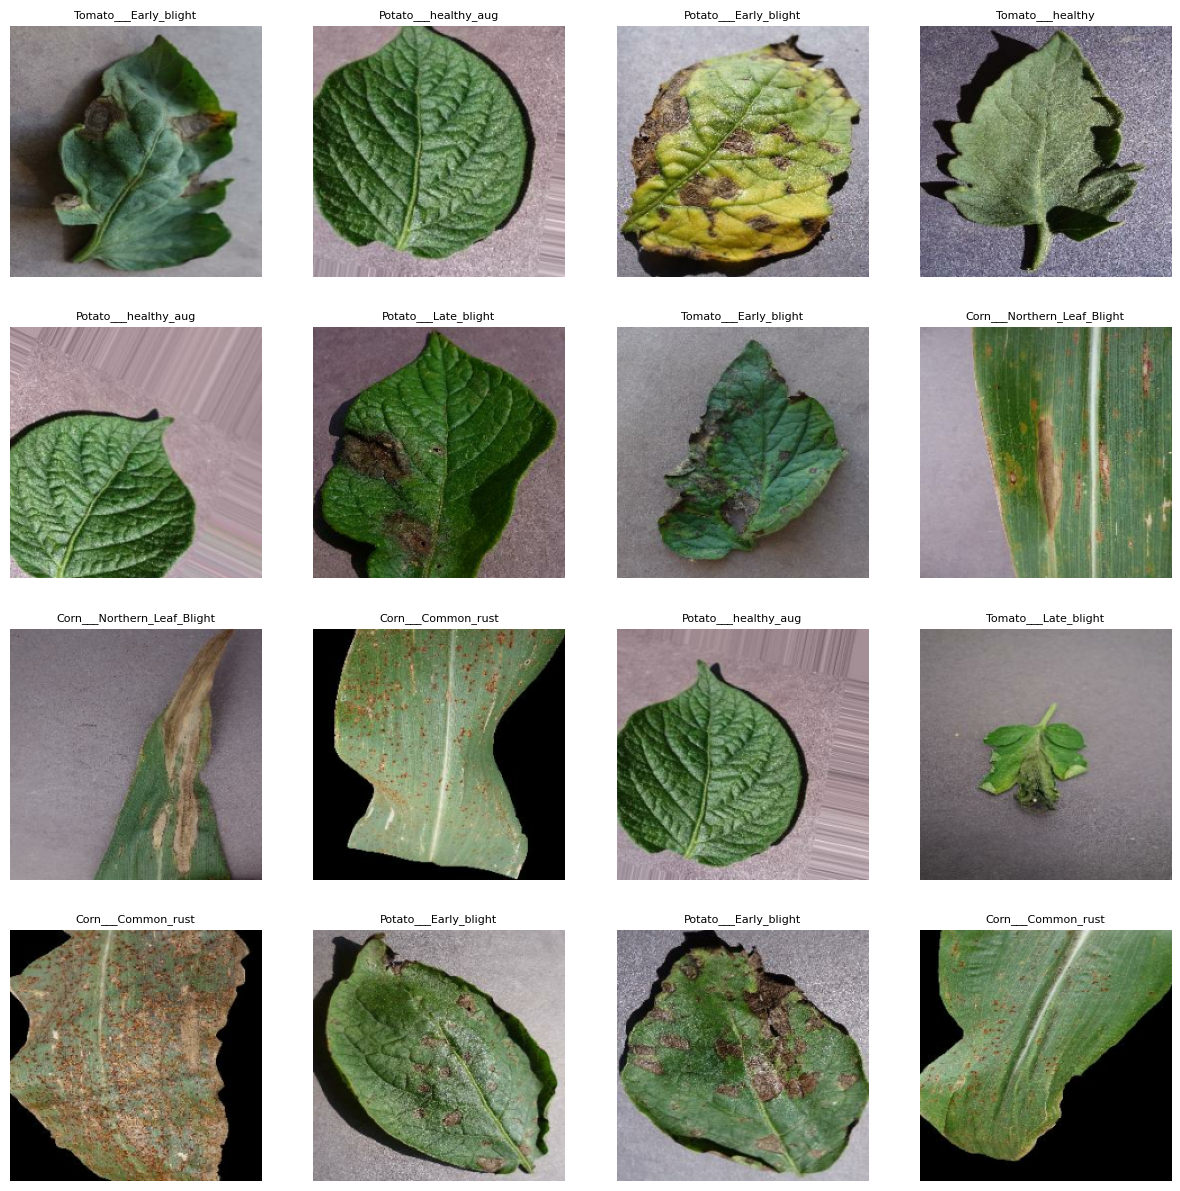

In [5]:
# Preview of random images from our classes 
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))
for images, labels in data.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(data.class_names[labels[i]], fontsize=8)
        plt.axis("off")
plt.show()

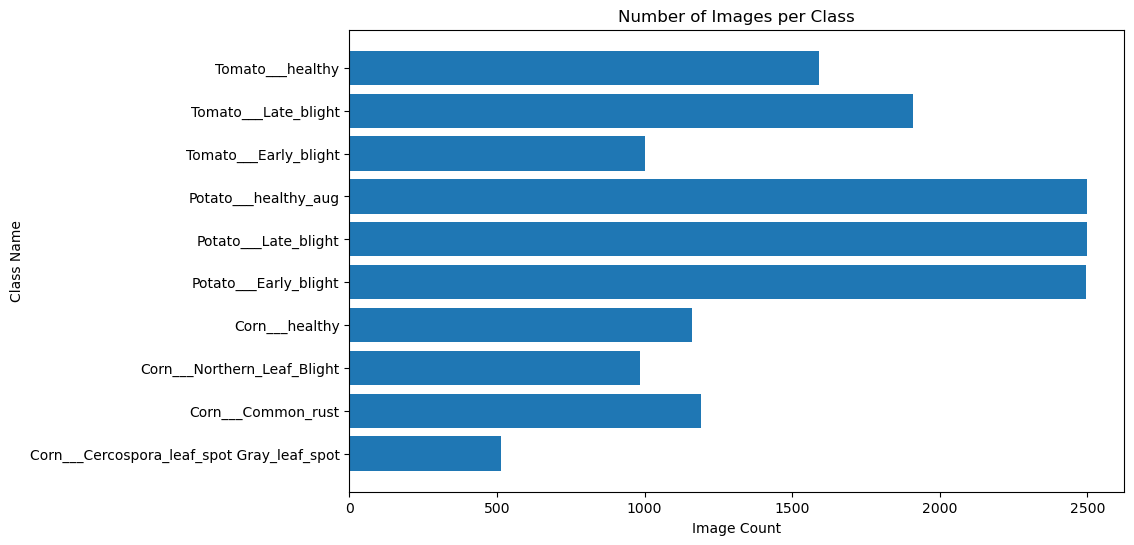

In [6]:
# count of the 10 classes
plt.figure(figsize=(10,6))
plt.barh(classes, [len(os.listdir(os.path.join(dataset_path, c))) for c in classes])
plt.title("Number of Images per Class")
plt.xlabel("Image Count")
plt.ylabel("Class Name")
plt.show()

# 4. Data Preparation

## Removing Duplicates

In [7]:
# Removing  duplicates
def remove_duplicates(dataset):
    seen = set()
    clean_images, clean_labels = [], []
    
    for images, labels in dataset:
        for i, img in enumerate(images):
            h = hashlib.md5(img.numpy().tobytes()).hexdigest()
            if h not in seen:
                seen.add(h)
                clean_images.append(img)
                clean_labels.append(labels[i])
    
    return tf.data.Dataset.from_tensor_slices(
        (tf.stack(clean_images), tf.stack(clean_labels))
    )

# Using the function
data = remove_duplicates(data)
print("Done")


Done


## Splitting the Data

In [8]:
import tensorflow as tf

dataset_path = "Plant disease dataset"

# First split: 70% train, 30% temp
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

# Second split: divide temp into 15% val and 15% test
val_batches = tf.data.experimental.cardinality(temp_ds)
val_ds = temp_ds.take(val_batches // 2)
test_ds = temp_ds.skip(val_batches // 2)

print(f" Train batches: {len(train_ds)}")
print(f" Validation batches: {len(val_ds)}")
print(f" Test batches: {len(test_ds)}")

Found 15848 files belonging to 10 classes.
Using 11094 files for training.
Found 15848 files belonging to 10 classes.
Using 4754 files for validation.
 Train batches: 347
 Validation batches: 74
 Test batches: 75


## Dealing with Class Imbalance

In [9]:
class_counts = {
    "Corn___Cercospora_leaf_spot Gray_leaf_spot": 513,
    "Corn___Common_rust": 1192,
    "Corn___Northern_Leaf_Blight": 985,
    "Corn___healthy": 1162,
    "Potato___Early_blight": 2495,
    "Potato___Late_blight": 2500,
    "Potato___healthy_aug": 2500,
    "Tomato___Early_blight": 1000,
    "Tomato___Late_blight": 1909,
    "Tomato___healthy": 1591
}

In [10]:
# Convert counts to class indices
classes = np.arange(len(class_counts))
counts = np.array(list(class_counts.values()))

# Compute class weights automatically
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=np.concatenate([[i]*count for i, count in enumerate(counts)])
)

# Convert to dictionary for model.fit()
class_weights = dict(enumerate(class_weights))

print("Computed Class Weights:")
for i, (cls, weight) in enumerate(zip(class_counts.keys(), class_weights.values())):
    print(f"{cls}: {weight:.3f}")


Computed Class Weights:
Corn___Cercospora_leaf_spot Gray_leaf_spot: 3.089
Corn___Common_rust: 1.329
Corn___Northern_Leaf_Blight: 1.609
Corn___healthy: 1.364
Potato___Early_blight: 0.635
Potato___Late_blight: 0.634
Potato___healthy_aug: 0.634
Tomato___Early_blight: 1.585
Tomato___Late_blight: 0.830
Tomato___healthy: 0.996


# 4. Modeling

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Simple CNN model
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax') 
])

model.summary()

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

| Layer               | Purpose                                             |
| ------------------- | --------------------------------------------------- |
| `Conv2D(32)`        | Detects simple features (edges, textures)           |
| `MaxPooling2D()` | Reduces image size to focus on main features        |
| `Conv2D(64)`        | Learns more complex patterns (disease spots, veins) |
| `MaxPooling2D()` | Further compresses spatial information              |
| `Flatten()`         | Converts 2D feature maps into a 1D vector           |
| `Dense(128, relu)`  | Learns complex relationships                        |
| `Dropout(0.3)`      | Reduces overfitting                                 |
| `Dense(10, softmax)` | Outputs probabilities for each disease class        |

In [26]:
# Compiling the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
# Training the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 260s 727ms/step - accuracy: 0.6895 - loss: 0.9083 - val_accuracy: 0.7998 - val_loss: 0.5301
Epoch 2/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 1063s 3s/step - accuracy: 0.8722 - loss: 0.3900 - val_accuracy: 0.8826 - val_loss: 0.3253
Epoch 3/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 188s 542ms/step - accuracy: 0.9073 - loss: 0.2843 - val_accuracy: 0.8708 - val_loss: 0.3759
Epoch 4/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 282s 814ms/step - accuracy: 0.9329 - loss: 0.2033 - val_accuracy: 0.9299 - val_loss: 0.2228
Epoch 5/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 302s 870ms/step - accuracy: 0.9448 - loss: 0.1850 - val_accuracy: 0.9113 - val_loss: 0.2515
Epoch 6/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 210s 605ms/step - accuracy: 0.9571 - loss: 0.1410 - val_accuracy: 0.9139 - val_loss: 0.3129
Epoch 7/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 217s 625ms/step - accuracy: 0.9648 - loss: 0.1064 - val_accuracy: 0.9350 - val_loss: 0.2168
Epoch 8/10
347/347 ━━━━━━━━━━━━━━━━━━━━ 3334s 10s/step - accuracy: 0.9711 - lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

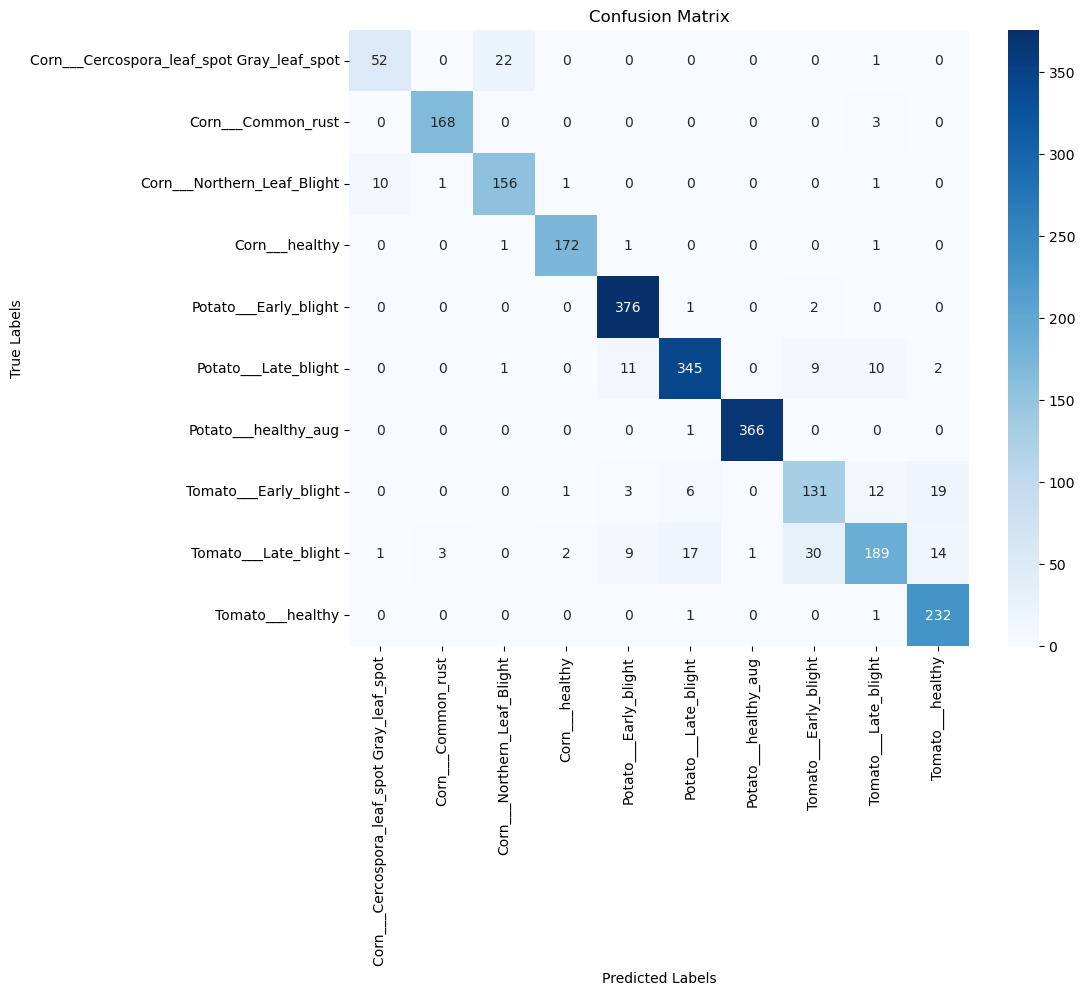

In [28]:
# Get class names from your dataset
class_names = train_ds.class_names

# Get model predictions on test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


## Transfer Learning

In [12]:
from tensorflow.keras.applications import MobileNetV2

# Load pretrained model without the top classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model so its weights don’t change during training
base_model.trainable = False

# Add your custom layers on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')  # 10 classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
# Compiling our model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
# Training the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 312s 845ms/step - accuracy: 0.7411 - loss: 0.7491 - val_accuracy: 0.8484 - val_loss: 0.4044
Epoch 2/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 288s 751ms/step - accuracy: 0.8447 - loss: 0.4438 - val_accuracy: 0.8602 - val_loss: 0.3366
Epoch 3/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 275s 791ms/step - accuracy: 0.8643 - loss: 0.3779 - val_accuracy: 0.8910 - val_loss: 0.2841
Epoch 4/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 261s 750ms/step - accuracy: 0.8793 - loss: 0.3481 - val_accuracy: 0.8948 - val_loss: 0.2663
Epoch 5/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 278s 802ms/step - accuracy: 0.8889 - loss: 0.3142 - val_accuracy: 0.8894 - val_loss: 0.2823


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 813ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 840ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 741ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 790ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 979ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 859ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 944ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 886ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 870ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 855ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 801

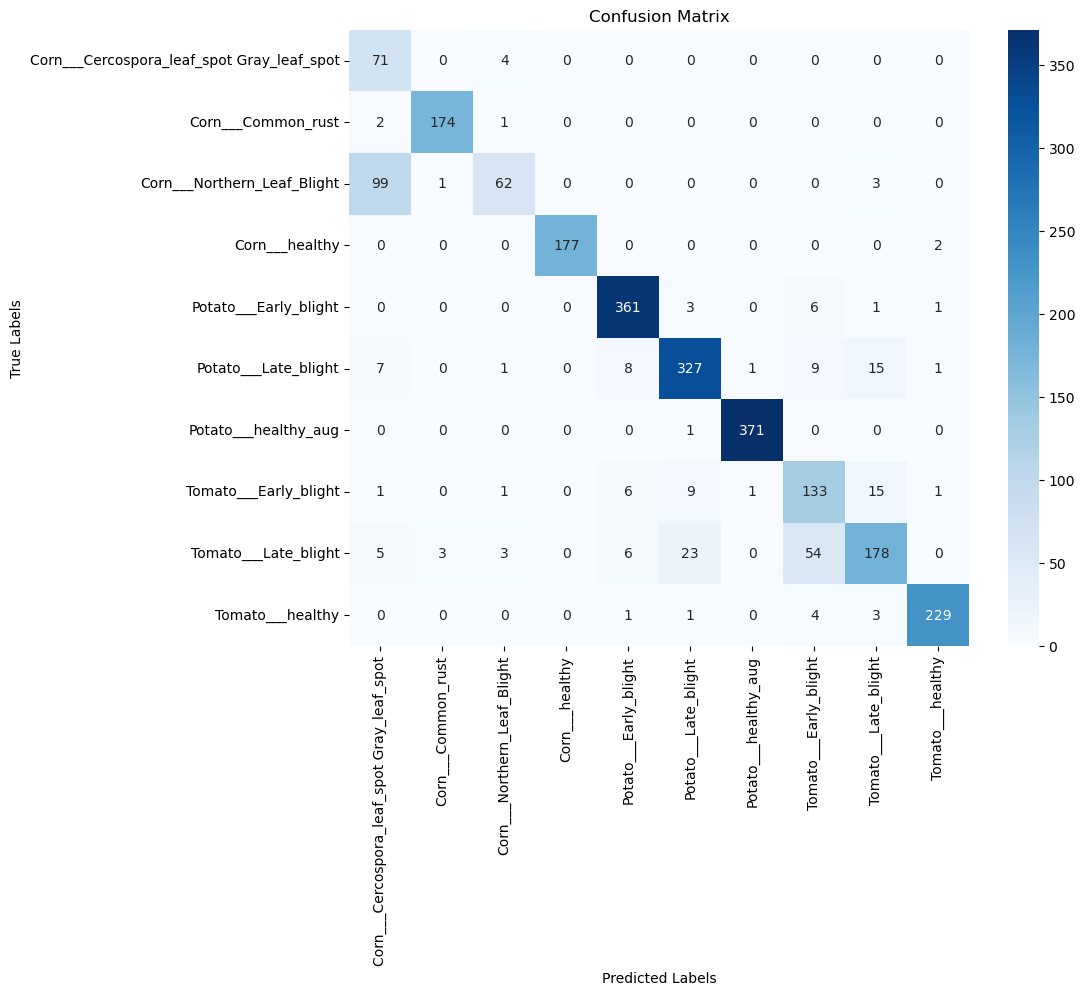

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# Get class names from your dataset
class_names = train_ds.class_names

# Get model predictions on test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# 5. Evaluation